# CAC 40 — IVol Exit / Derivative Re-entry Explorer

**Two sliders, one chart:**
- **Exit threshold**: go flat when IVol ≥ X
- **Re-entry days**: re-enter after N consecutive days of falling IVol

Price is **green** when in the market, **red** when flat.

In [5]:
import sys
import pandas as pd, numpy as np
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')

# ── Signum charting ──
sys.path.insert(0, r"C:\Personal\Business & Investments\Python codes")
from signum import Chart, Dashboard

# ── Sfera DB ──
import sfera_db

PROJECT_ROOT = Path(r"c:\Personal\Business & Investments\Trading portfolio\Cogilator\btest")

In [6]:

# ── Load CAC (price, ivol, total return) ──
cac_px   = sfera_db.index_prices('CAC')[['close', 'volume']]
cac_ivol = sfera_db.index_ivol('CAC')[['ivol']]
try:
    cac_tr_raw = sfera_db.read_table('index_total_return', ticker='CACT')[['close_price']]
    cac_tr_px  = cac_tr_raw.rename(columns={'close_price': 'close'})
    has_tr = True
except Exception:
    cac_tr_px = None; has_tr = False

common_idx = cac_px.index.intersection(cac_ivol.index)
if has_tr:
    common_idx = common_idx.intersection(cac_tr_px.index)

cac = pd.DataFrame({'close': cac_px.loc[common_idx, 'close'],
                    'ivol':  cac_ivol.loc[common_idx, 'ivol']}).sort_index()
cac['ret'] = cac['close'].pct_change()
if has_tr:
    cac['close_tr'] = cac_tr_px.loc[common_idx, 'close']
    cac['ret_tr']   = cac['close_tr'].pct_change()
    clean = cac.dropna(subset=['ret', 'ret_tr']).copy()
else:
    cac['ret_tr'] = cac['ret']
    clean = cac.dropna(subset=['ret']).copy()
clean['ivol_ema5']  = clean['ivol'].ewm(span=5).mean()
clean['ivol_ema20'] = clean['ivol'].ewm(span=20).mean()

# ── Load LVC (2× CAC, Amundi) ──
LVC_CSV = Path(r"C:\Personal\Business & Investments\Trading portfolio\Strategies\ETF TKAN\Data\lvc_ohlcv.csv")
lvc_raw = pd.read_csv(LVC_CSV, parse_dates=['date'], index_col='date').sort_index()
common_lvc = clean.index.intersection(lvc_raw.index)
lvc = pd.DataFrame({
    'close': lvc_raw.loc[common_lvc, 'close'],
    'ivol':  clean.loc[common_lvc, 'ivol'],
    'ret':   lvc_raw.loc[common_lvc, 'close'].pct_change(),
}).dropna()
lvc_bh_eq     = (1 + lvc['ret']).cumprod()
lvc_bh_sharpe = lvc['ret'].mean() / lvc['ret'].std() * np.sqrt(252)


In [7]:
# ── Overview: CAC 40 / LVC / CAC TR (base-100) + IVol ──
bh_eq     = (1 + clean['ret']).cumprod()
bh_sharpe = clean['ret'].mean() / clean['ret'].std() * np.sqrt(252)
bh_mdd    = ((bh_eq - bh_eq.cummax()) / bh_eq.cummax()).min() * 100
print(f"CAC B&H  Sharpe {bh_sharpe:.3f}  Total {(bh_eq.iloc[-1]-1)*100:+.1f}%  MaxDD {bh_mdd:.1f}%")
print(f"LVC B&H  Sharpe {lvc_bh_sharpe:.3f}  Total {(lvc_bh_eq.iloc[-1]-1)*100:+.1f}%")

t_lvc = lvc.index
def _norm(s): return s / s.iloc[0] * 100

p_prices = (
    Chart(height=300)
    .line(pd.DataFrame({'time': t_lvc, 'value': _norm(clean.loc[t_lvc, 'close']).values}),
          name='CAC 40 PR', color='#60a5fa', width=2)
    .line(pd.DataFrame({'time': t_lvc, 'value': _norm(lvc['close']).values}),
          name='LVC 2×', color='#a78bfa', width=2)
)
if has_tr:
    p_prices = p_prices.line(
        pd.DataFrame({'time': t_lvc, 'value': _norm(clean.loc[t_lvc, 'close_tr']).values}),
        name='CAC TR', color='#34d399', width=1
    )

# IVol restricted to t_lvc so both panes share the exact same date range
p_ivol = (
    Chart(height=220)
    .line(pd.DataFrame({'time': t_lvc, 'value': clean.loc[t_lvc, 'ivol'].values}),      name='IVol',   color='#fb923c', width=1)
    .line(pd.DataFrame({'time': t_lvc, 'value': clean.loc[t_lvc, 'ivol_ema5'].values}),  name='EMA-5',  color='#fbbf24', width=1)
    .line(pd.DataFrame({'time': t_lvc, 'value': clean.loc[t_lvc, 'ivol_ema20'].values}), name='EMA-20', color='#a78bfa', width=1)
)


Dashboard(panes=[p_prices, p_ivol], titles=['CAC 40 PR / LVC 2× / CAC TR  (base-100)', 'Implied Volatility + EMAs'], theme='dark')

CAC B&H  Sharpe 0.182  Total +36.5%  MaxDD -59.2%
LVC B&H  Sharpe 0.299  Total +95.6%


In [8]:

# ── Year-by-year returns & annualised volatility — CAC PR / CAC TR / LVC B&H ──
# All three restricted to the common LVC window (= t_lvc) for an apples-to-apples comparison
_pr_ret  = clean.loc[t_lvc, 'ret']
_tr_ret  = clean.loc[t_lvc, 'ret_tr']
_lvc_ret = lvc['ret']

def _ann_ret(s):  return (1 + s).resample('YE').prod() - 1
def _ann_vol(s):  return s.resample('YE').std() * np.sqrt(252) * 100

_years   = _ann_ret(_pr_ret).index.year
_ret_tbl = pd.DataFrame({
    'CAC PR %':   (_ann_ret(_pr_ret)  * 100).values,
    'CAC TR %':   (_ann_ret(_tr_ret)  * 100).values,
    'LVC B&H %':  (_ann_ret(_lvc_ret) * 100).values,
    'Vol PR %':   _ann_vol(_pr_ret).values,
    'Vol TR %':   _ann_vol(_tr_ret).values,
    'Vol LVC %':  _ann_vol(_lvc_ret).values,
}, index=_years).round(1)

# Append a full-period summary row
_ret_tbl.loc['Full period'] = [
    round(((1 + _pr_ret).prod()  - 1) * 100, 1),
    round(((1 + _tr_ret).prod()  - 1) * 100, 1),
    round(((1 + _lvc_ret).prod() - 1) * 100, 1),
    round(_pr_ret.std()  * np.sqrt(252) * 100, 1),
    round(_tr_ret.std()  * np.sqrt(252) * 100, 1),
    round(_lvc_ret.std() * np.sqrt(252) * 100, 1),
]

_ret_cols = ['CAC PR %', 'CAC TR %', 'LVC B&H %']
_vol_cols = ['Vol PR %', 'Vol TR %', 'Vol LVC %']

display(
    _ret_tbl.style
    .background_gradient(subset=pd.IndexSlice[_years, _ret_cols], cmap='RdYlGn', vmin=-40, vmax=60, axis=None)
    .background_gradient(subset=pd.IndexSlice[_years, _vol_cols], cmap='RdYlGn_r', vmin=10, vmax=55, axis=None)
    .format({c: '{:+.1f}' for c in _ret_cols} | {c: '{:.1f}' for c in _vol_cols})
    .set_caption('Year-by-year returns & annualised volatility — CAC PR / CAC TR / LVC B&H  (common LVC period)')
)


,CAC PR %,CAC TR %,LVC B&H %,Vol PR %,Vol TR %,Vol LVC %
2008,-34.8,-33.4,-64.1,47.1,47.3,93.3
2009,+22.3,+27.6,+36.7,26.5,26.5,51.6
2010,-2.2,+1.8,-11.1,23.6,23.5,40.4
2011,-17.9,-14.4,-34.8,28.5,28.4,55.7
2012,+14.6,+19.7,+34.9,20.8,20.8,40.3
2013,+18.7,+22.9,+44.9,16.2,16.2,31.5
2014,-0.5,+2.7,+0.7,16.2,16.1,31.5
2015,+9.5,+12.9,+20.8,22.5,22.4,44.0
2016,+4.0,+7.9,+9.9,20.8,21.0,41.6
2017,+9.3,+12.7,+24.6,10.5,10.5,20.7


In [9]:

# ── IVol threshold explorer ──
# Long when IVol < threshold, flat (cash) when IVol >= threshold

ivol_min = int(clean['ivol'].min())
ivol_max = int(clean['ivol'].max()) + 1
ivol_med = int(clean['ivol'].quantile(0.70))  # default: p70

sl_thr = widgets.IntSlider(
    value=ivol_med, min=ivol_min, max=ivol_max, step=1,
    description='IVol threshold',
    continuous_update=False,
    style={'description_width': '130px'},
    layout=widgets.Layout(width='70%')
)
out = widgets.Output()

def _draw(threshold):
    t = clean.index
    position  = (clean['ivol'] < threshold).astype(float)
    # shift(1): signal observed at close[T] → trade executes at open[T+1]
    # fillna(1): day-1 default is long — IVol is assumed normal at inception
    strat_ret = position.shift(1).fillna(1) * clean['ret']
    equity    = (1 + strat_ret).cumprod()
    pct_in    = position.mean() * 100
    sr        = strat_ret
    sharpe    = sr.mean() / sr.std() * np.sqrt(252) if sr.std() > 0 else 0
    total     = (equity.iloc[-1] - 1) * 100
    mdd       = ((equity - equity.cummax()) / equity.cummax()).min() * 100

    pos_in  = pd.DataFrame({'time': t, 'position': position.shift(1).fillna(1).values})
    pos_out = pd.DataFrame({'time': t, 'position': (1 - position.shift(1).fillna(1)).values})

    p_price = (
        Chart(height=300)
        .line(pd.DataFrame({'time': t, 'value': clean['close'].values}),
              name='CAC 40', color='#60a5fa', width=2)
        .shade(pos_in, position_col='position', color='#34d399', opacity=0.08)
    )

    p_ivol = (
        Chart(height=220)
        .line(pd.DataFrame({'time': t, 'value': clean['ivol'].values}),
              name='IVol', color='#fb923c', width=1)
        .price_line(price=float(threshold), title=f'{threshold}',
                    color='#f87171', line_style=2, line_width=1)
        .shade(pos_out, position_col='position', color='#f87171', opacity=0.12)
    )

    p_eq = (
        Chart(height=180)
        .line(pd.DataFrame({'time': t, 'value': equity.values}),
              name='Strategy', color='#34d399', width=2)
        .line(pd.DataFrame({'time': bh_eq.index, 'value': bh_eq.values}),
              name='Buy & Hold', color='#6b7280', width=1)
    )

    return Dashboard(
        panes=[p_price, p_ivol, p_eq],
        titles=[
            f'CAC 40 — long when IVol < {threshold}  ({pct_in:.0f}% in market)',
            f'Implied Volatility  (threshold = {threshold})',
            f'Sharpe {sharpe:.3f}   Total {total:+.1f}%   MaxDD {mdd:.1f}%',
        ],
        theme='dark'
    )

def _on_change(change):
    with out:
        from IPython.display import clear_output
        clear_output(wait=True)
        display(_draw(change['new']))

sl_thr.observe(_on_change, names='value')

with out:
    display(_draw(sl_thr.value))

display(widgets.VBox([sl_thr, out]))


## Verdict — Fixed IVol Threshold on CAC 40

Across the full IVol range the **fixed threshold strategy consistently delivers a lower Sharpe than simply buying-and-holding the CAC 40 index**:

- Low thresholds → too little time in market, miss large upward moves
- High thresholds → nearly always invested, almost identical to B&H but with extra friction
- No threshold level offers a meaningful Sharpe improvement over B&H

**Conclusion:** a fixed IVol level provides no benefit on the CAC 40 index. The signal is not strong enough to justify the missed upside.

**Next question:** does the same signal work better on **LVC (2× CAC)**? Leverage amplifies IVol-driven drawdowns, so the protection may be worth more than the lost upside cost.


In [10]:
# LVC data and B&H stats are loaded in the data cell above — nothing to do here.
# lvc, lvc_bh_eq, lvc_bh_sharpe, t_lvc are all available.


In [15]:

# ── IVol threshold explorer — LVC (2× CAC) ──
lvc_bh_eq     = (1 + lvc['ret']).cumprod()
lvc_bh_sharpe = lvc['ret'].mean() / lvc['ret'].std() * np.sqrt(252)
print(f"LVC B&H  Sharpe {lvc_bh_sharpe:.3f}  Total {(lvc_bh_eq.iloc[-1]-1)*100:+.1f}%")

ivol_min_l = int(lvc['ivol'].min())
ivol_max_l = int(lvc['ivol'].max()) + 1
ivol_med_l = int(lvc['ivol'].quantile(0.70))

sl_lvc = widgets.IntSlider(
    value=ivol_med_l, min=ivol_min_l, max=ivol_max_l, step=1,
    description='IVol threshold',
    continuous_update=False,
    style={'description_width': '130px'},
    layout=widgets.Layout(width='70%')
)
out_lvc = widgets.Output()

def _draw_lvc(threshold):
    t = lvc.index
    position  = (lvc['ivol'] < threshold).astype(float)
    # shift(1): signal observed at close[T] → trade executes at open[T+1]
    # fillna(1): day-1 default is long — IVol is assumed normal at inception
    strat_ret = position.shift(1).fillna(1) * lvc['ret']
    equity    = (1 + strat_ret).cumprod()
    pct_in    = position.mean() * 100
    sharpe    = strat_ret.mean() / strat_ret.std() * np.sqrt(252) if strat_ret.std() > 0 else 0
    total     = (equity.iloc[-1] - 1) * 100
    mdd       = ((equity - equity.cummax()) / equity.cummax()).min() * 100

    pos_in  = pd.DataFrame({'time': t, 'position': position.shift(1).fillna(1).values})
    pos_out = pd.DataFrame({'time': t, 'position': (1 - position.shift(1).fillna(1)).values})

    p_price = (
        Chart(height=300)
        .line(pd.DataFrame({'time': t, 'value': lvc['close'].values}),
              name='LVC 2×', color='#a78bfa', width=2)
        .shade(pos_in, position_col='position', color='#34d399', opacity=0.08)
    )

    p_ivol = (
        Chart(height=220)
        .line(pd.DataFrame({'time': t, 'value': lvc['ivol'].values}),
              name='CAC IVol', color='#fb923c', width=1)
        .price_line(price=float(threshold), title=f'{threshold}',
                    color='#f87171', line_style=2, line_width=1)
        .shade(pos_out, position_col='position', color='#f87171', opacity=0.12)
    )

    p_eq = (
        Chart(height=180)
        .line(pd.DataFrame({'time': t, 'value': equity.values}),
              name='Strategy', color='#34d399', width=2)
        .line(pd.DataFrame({'time': lvc_bh_eq.index, 'value': lvc_bh_eq.values}),
              name='LVC B&H', color='#6b7280', width=1)
    )

    return Dashboard(
        panes=[p_price, p_ivol, p_eq],
        titles=[
            f'LVC 2× — long when IVol < {threshold}  ({pct_in:.0f}% in market)',
            f'CAC Implied Volatility  (threshold = {threshold})',
            f'Sharpe {sharpe:.3f}   Total {total:+.1f}%   MaxDD {mdd:.1f}%',
        ],
        theme='dark'
    )

def _on_change_lvc(change):
    with out_lvc:
        from IPython.display import clear_output
        clear_output(wait=True)
        display(_draw_lvc(change['new']))

sl_lvc.observe(_on_change_lvc, names='value')

with out_lvc:
    display(_draw_lvc(sl_lvc.value))

display(widgets.VBox([sl_lvc, out_lvc]))


LVC B&H  Sharpe 0.299  Total +95.6%


## Verdict — Fixed IVol Threshold on LVC (2× CAC)

Unlike the unlevered index, **exiting LVC when CAC IVol ≥ ~40–45 meaningfully improves risk-adjusted performance**:

- Sharpe improves to ~0.37 vs LVC B&H baseline
- Total PnL is higher — the leverage amplification works *against* you during high-IVol regimes enough that sitting in cash is profitable
- The protection benefit outweighs the cost of missed upside at this threshold band

**Why it works on LVC but not CAC:**
Leverage doubles both gains and losses. During high-IVol periods (crises, corrections) the drawdowns on LVC are severe enough that avoiding them more than compensates for the days out of market. On the unleveraged index the same drawdowns are too shallow to make the trade-off worthwhile.

**Next steps:** explore a *dynamic* threshold (IVol relative to its own rolling mean / Z-score) rather than a fixed level — this would adapt to secular IVol regime shifts and likely generalise better out-of-sample.


## Dynamic IVol Signals — LVC

If a fixed threshold has regime-drift problems, can we use *relative* IVol measures instead?

| Signal | Logic | Idea |
|---|---|---|
| **Fixed level** | long when IVol < X | baseline |
| **IVol vs EMA(N)** | long when IVol < its own N-day EMA | exit when IVol breaks above trend |
| **IVol momentum(N)** | long when N-day IVol change ≤ 0 | exit as soon as vol starts spiking |
| **IVol Z-score(W)** | long when rolling Z-score < 1.0 | regime-normalised, adapts to vol-of-vol |
| **EMA crossover(fast, slow=40)** | long when EMA-fast < EMA-slow | classic vol trend-change signal |

Comparison table uses default parameters. Explorer lets you tune them interactively.


In [16]:

# ── Dynamic signal helpers + comparison table ──

def _position(sig, p1, p2=None):
    ivol = lvc['ivol']
    if sig == 'Fixed level':
        return (ivol < p1).astype(float)
    elif sig == 'IVol vs EMA':
        return (ivol < ivol.ewm(span=int(p1)).mean()).astype(float)
    elif sig == 'IVol momentum':
        return (ivol.diff(int(p1)) <= 0).fillna(False).astype(float)
    elif sig == 'IVol Z-score':
        rm = ivol.rolling(int(p1)).mean()
        rs = ivol.rolling(int(p1)).std()
        return ((ivol - rm) / rs < float(p2)).fillna(True).astype(float)
    elif sig == 'EMA crossover':
        return (ivol.ewm(span=int(p1)).mean() < ivol.ewm(span=int(p2)).mean()).astype(float)

def _perf(pos):
    # lag=1 day: signal observed at close[T] → execute at open[T+1]
    # fillna(0) = stay flat (cash) until first valid signal is established
    lagged = pos.shift(1).fillna(0)
    sr  = lagged * lvc['ret']
    eq  = (1 + sr).cumprod()
    sh  = sr.mean() / sr.std() * np.sqrt(252) if sr.std() > 0 else 0
    mdd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    return {
        'Sharpe':    round(sh, 3),
        'Total %':   round((eq.iloc[-1] - 1) * 100, 1),
        'MaxDD %':   round(mdd, 1),
        '% in-mkt':  round(lagged.mean() * 100, 1),
        '_eq':       eq,
    }

# Default params for comparison table
DEFAULTS = [
    ('Fixed level',   42,   None, 'IVol < 42'),
    ('IVol vs EMA',   20,   None, 'IVol < EMA-20'),
    ('IVol momentum',  5,   None, 'Δ5d IVol ≤ 0'),
    ('IVol Z-score',  90,   1.0,  'Z(90d) < 1.0'),
    ('EMA crossover',  5,   40,   'EMA-5 < EMA-40'),
]

rows = []
for sig, p1, p2, desc in DEFAULTS:
    pos  = _position(sig, p1, p2)
    perf = _perf(pos)
    rows.append({'Signal': desc, **{k: v for k, v in perf.items() if not k.startswith('_')}})

bh_mdd_lvc = ((lvc_bh_eq - lvc_bh_eq.cummax()) / lvc_bh_eq.cummax()).min() * 100
rows.append({
    'Signal':   'LVC B&H',
    'Sharpe':   round(lvc_bh_sharpe, 3),
    'Total %':  round((lvc_bh_eq.iloc[-1] - 1) * 100, 1),
    'MaxDD %':  round(bh_mdd_lvc, 1),
    '% in-mkt': 100.0,
})

tbl = pd.DataFrame(rows).set_index('Signal')
display(
    tbl.style
    .background_gradient(subset=['Sharpe'], cmap='RdYlGn', vmin=0.0, vmax=0.6)
    .set_caption('Dynamic IVol Signals — LVC  (default parameters)')
    .format({'Sharpe': '{:.3f}', 'Total %': '{:+.1f}', 'MaxDD %': '{:.1f}', '% in-mkt': '{:.1f}'})
)


,Sharpe,Total %,MaxDD %,% in-mkt
Signal,,,,
IVol < 42,0.372,+245.0,-59.9,98.6
IVol < EMA-20,0.390,+240.2,-56.2,59.3
Δ5d IVol ≤ 0,0.307,+131.2,-80.4,54.0
Z(90d) < 1.0,0.430,+366.7,-56.9,80.2
EMA-5 < EMA-40,0.092,-14.4,-59.3,60.2
LVC B&H,0.299,+95.6,-78.2,100.0


In [17]:

# ── Dynamic IVol signal explorer — LVC ──
# Dropdown picks signal type; p1 slider tunes the primary parameter.
# Secondary param (Z threshold / slow EMA period) is fixed at sensible defaults.

# p2 fixed defaults per signal (for explorer; table above used same values)
_P2_FIXED = {'Fixed level': None, 'IVol vs EMA': None,
             'IVol momentum': None, 'IVol Z-score': 1.0, 'EMA crossover': 40}

# p1 slider config per signal: (label, min, max, default, step)
_P1_CFG = {
    'Fixed level':   ('IVol threshold', 10,  79, 42, 1),
    'IVol vs EMA':   ('EMA period',      5, 120, 20, 1),
    'IVol momentum': ('Lookback days',   1,  30,  5, 1),
    'IVol Z-score':  ('Window days',    20, 252, 90, 5),
    'EMA crossover': ('Fast period',     2,  30,  5, 1),
}

dd_dyn = widgets.Dropdown(
    options=list(_P1_CFG.keys()), value='IVol vs EMA',
    description='Signal:', style={'description_width': '70px'},
    layout=widgets.Layout(width='45%')
)
sl_dyn = widgets.IntSlider(
    continuous_update=False,
    style={'description_width': '130px'},
    layout=widgets.Layout(width='70%')
)
out_dyn = widgets.Output()

def _apply_p1_cfg(sig):
    label, mn, mx, default, step = _P1_CFG[sig]
    # reset bounds safely before setting value
    sl_dyn.min, sl_dyn.max = 1, 10000
    sl_dyn.description = label
    sl_dyn.step = step
    sl_dyn.value = default
    sl_dyn.min, sl_dyn.max = mn, mx

_apply_p1_cfg(dd_dyn.value)

def _ivol_pane(sig, p1, pos_out):
    t = lvc.index
    ivol = lvc['ivol']
    c = (Chart(height=200)
         .line(pd.DataFrame({'time': t, 'value': ivol.values}),
               name='IVol', color='#fb923c', width=1)
         .shade(pos_out, position_col='position', color='#f87171', opacity=0.12))
    if sig == 'Fixed level':
        c = c.price_line(price=float(p1), title=f'{p1}',
                         color='#f87171', line_style=2, line_width=1)
    elif sig == 'IVol vs EMA':
        ema = ivol.ewm(span=int(p1)).mean()
        c = c.line(pd.DataFrame({'time': t, 'value': ema.values}),
                   name=f'EMA-{p1}', color='#a78bfa', width=1)
    elif sig == 'EMA crossover':
        ef = ivol.ewm(span=int(p1)).mean()
        es = ivol.ewm(span=40).mean()
        c = (c.line(pd.DataFrame({'time': t, 'value': ef.values}),
                    name=f'EMA-{p1}', color='#34d399', width=1)
              .line(pd.DataFrame({'time': t, 'value': es.values}),
                    name='EMA-40', color='#6b7280', width=1))
    elif sig == 'IVol Z-score':
        rm = ivol.rolling(int(p1)).mean()
        c = c.line(pd.DataFrame({'time': t, 'value': rm.values}),
                   name=f'Mean-{p1}d', color='#a78bfa', width=1)
    return c

def _draw_dyn(sig, p1):
    p2   = _P2_FIXED[sig]
    pos  = _position(sig, p1, p2)
    perf = _perf(pos)
    t    = lvc.index
    # lag=1 day: signal observed at close[T] → execute at open[T+1]
    # fillna(0) = stay flat (cash) until first valid signal is established
    lagged  = pos.shift(1).fillna(0)
    pos_in  = pd.DataFrame({'time': t, 'position': lagged.values})
    pos_out = pd.DataFrame({'time': t, 'position': (1 - lagged).values})

    p_price = (
        Chart(height=300)
        .line(pd.DataFrame({'time': t, 'value': lvc['close'].values}),
              name='LVC 2×', color='#a78bfa', width=2)
        .shade(pos_in, position_col='position', color='#34d399', opacity=0.08)
    )
    p_ivol_d = _ivol_pane(sig, p1, pos_out)
    p_eq = (
        Chart(height=180)
        .line(pd.DataFrame({'time': t, 'value': perf['_eq'].values}),
              name='Strategy', color='#34d399', width=2)
        .line(pd.DataFrame({'time': lvc_bh_eq.index, 'value': lvc_bh_eq.values}),
              name='LVC B&H', color='#6b7280', width=1)
    )
    p2_str = f'  p2={p2}' if p2 is not None else ''
    return Dashboard(
        panes=[p_price, p_ivol_d, p_eq],
        titles=[
            f'LVC 2×  —  {sig}  (p1={p1}{p2_str})  |  {perf["% in-mkt"]:.0f}% in market',
            'CAC Implied Volatility',
            f'Sharpe {perf["Sharpe"]:.3f}   Total {perf["Total %"]:+.1f}%   MaxDD {perf["MaxDD %"]:.1f}%',
        ],
        theme='dark'
    )

def _refresh_dyn(*_):
    with out_dyn:
        from IPython.display import clear_output
        clear_output(wait=True)
        display(_draw_dyn(dd_dyn.value, sl_dyn.value))

def _on_sig(change):
    _apply_p1_cfg(change['new'])
    _refresh_dyn()

dd_dyn.observe(_on_sig, names='value')
sl_dyn.observe(_refresh_dyn, names='value')

with out_dyn:
    display(_draw_dyn(dd_dyn.value, sl_dyn.value))

display(widgets.VBox([dd_dyn, sl_dyn, out_dyn]))


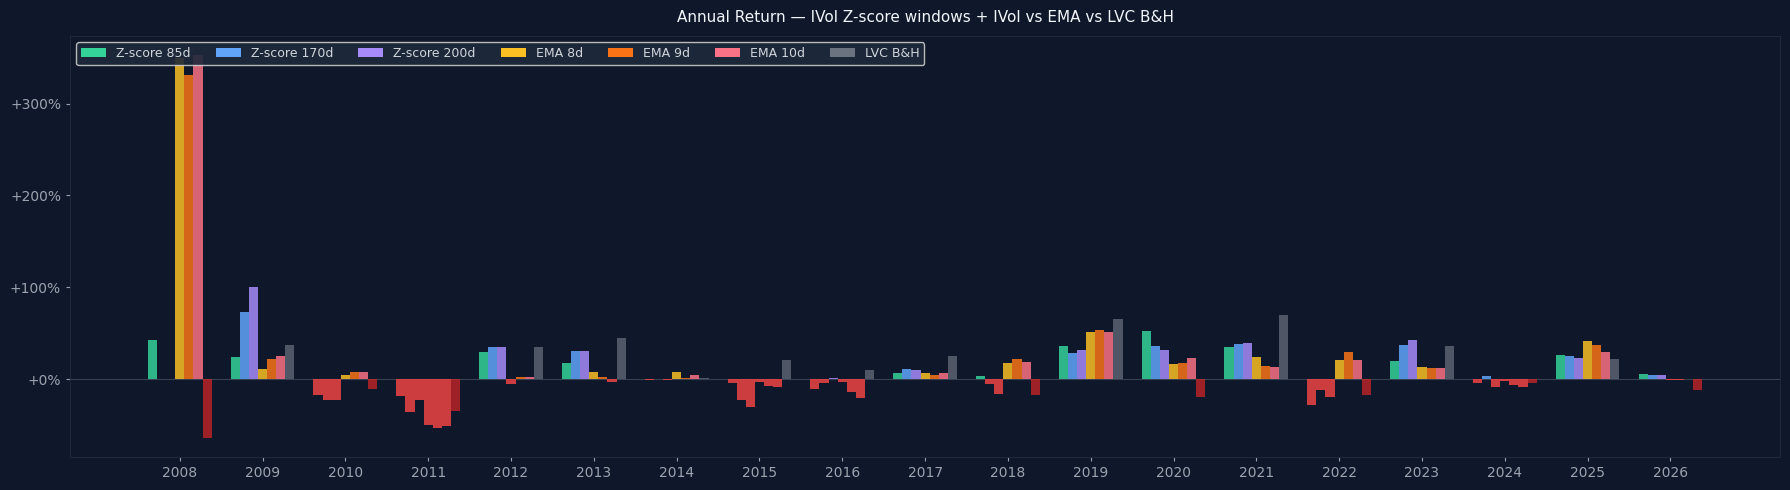

,CAC PR %,CAC TR %,LVC B&H %,Z 85d %,Δ Z85d,Z 170d %,Δ Z170d,Z 200d %,Δ Z200d,EMA 8d %,Δ EMA8d,EMA 9d %,Δ EMA9d,EMA 10d %,Δ EMA10d
2008,-34.8,-33.4,-64.1,+42.5,+106.6,+0.0,+64.1,+0.0,+64.1,+350.3,+414.4,+331.8,+395.9,+353.0,+417.2
2009,+22.3,+27.6,+36.7,+24.1,-12.6,+73.2,+36.5,+100.4,+63.7,+11.1,-25.6,+21.4,-15.3,+25.4,-11.3
2010,-2.2,+1.8,-11.1,-17.6,-6.5,-22.8,-11.7,-22.6,-11.5,+4.6,+15.7,+7.1,+18.2,+7.6,+18.7
2011,-17.9,-14.4,-34.8,-18.5,+16.3,-35.4,-0.7,-22.5,+12.3,-50.5,-15.8,-53.6,-18.8,-51.4,-16.7
2012,+14.6,+19.7,+34.9,+29.6,-5.3,+34.9,+0.0,+34.9,+0.0,-4.9,-39.8,+1.9,-33.0,+2.1,-32.8
2013,+18.7,+22.9,+44.9,+17.5,-27.4,+30.6,-14.3,+30.7,-14.1,+7.4,-37.5,+2.2,-42.7,-3.4,-48.3
2014,-0.5,+2.7,+0.7,-1.5,-2.2,+0.2,-0.5,-1.3,-2.0,+8.1,+7.4,+1.1,+0.4,+4.6,+3.9
2015,+9.5,+12.9,+20.8,-4.7,-25.5,-22.7,-43.5,-30.5,-51.3,-3.5,-24.3,-7.8,-28.6,-9.0,-29.8
2016,+4.0,+7.9,+9.9,-11.3,-21.2,-4.2,-14.1,+1.3,-8.6,-3.5,-13.4,-13.7,-23.6,-21.0,-30.9
2017,+9.3,+12.7,+24.6,+7.0,-17.7,+11.0,-13.6,+10.3,-14.3,+6.4,-18.2,+4.1,-20.5,+6.7,-17.9


,Total Return %,Ann. Vol %,Sharpe,Vol of Sharpe,IR vs LVC B&H,Vol of IR (LVC),IR vs CAC PR,IR vs CAC TR
Strategy,,,,,,,,
Z 85d,+408.5,30.8,0.446,0.763,0.043,1.377,0.414,0.263
Z 170d,+365.2,30.3,0.432,0.766,0.019,1.303,0.395,0.240
Z 200d,+340.6,29.7,0.425,0.874,0.003,1.332,0.371,0.217
EMA 8d,+1245.5,27.5,0.658,1.299,0.177,1.623,0.562,0.424
EMA 9d,+937.1,27.5,0.607,1.329,0.131,1.654,0.501,0.363
EMA 10d,+834.3,27.3,0.587,1.324,0.111,1.694,0.475,0.338
LVC B&H,+95.6,41.9,0.299,1.022,—,—,—,—
CAC PR,+55.4,21.4,0.221,0.957,—,—,—,—
CAC TR,+181.0,21.4,0.374,1.002,—,—,—,—


,LVC B&H,CAC PR,CAC TR,Z 85d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,-1.310,-1.230,-1.156,2.035,0.000,0.000,4.641,4.523,4.698
2009,0.854,0.880,1.036,0.670,1.338,1.793,0.460,0.671,0.749
2010,-0.085,0.025,0.190,-0.369,-0.600,-0.593,0.300,0.390,0.410
2011,-0.473,-0.538,-0.396,-0.309,-1.052,-0.571,-1.622,-1.822,-1.712
2012,0.939,0.754,0.965,0.867,0.939,0.939,-0.031,0.208,0.214
2013,1.321,1.127,1.340,0.721,1.028,1.028,0.467,0.206,-0.088
2014,0.180,0.047,0.244,0.049,0.132,0.069,0.487,0.151,0.330
2015,0.644,0.510,0.648,0.009,-0.658,-1.031,0.004,-0.178,-0.235
2016,0.434,0.288,0.463,-0.190,0.048,0.208,0.031,-0.351,-0.673
2017,1.154,0.884,1.182,0.464,0.665,0.625,0.503,0.355,0.525


,Z 85d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,2.095,1.310,1.310,5.490,5.367,5.468
2009,-1.578,1.608,1.231,-0.791,-0.527,-0.425
2010,-0.469,-0.720,-0.713,0.359,0.434,0.452
2011,0.360,-0.241,0.159,-0.871,-1.018,-0.908
2012,-0.366,0.000,0.000,-1.372,-1.136,-1.129
2013,-1.387,-1.108,-1.163,-1.299,-1.531,-1.708
2014,-0.208,-0.123,-0.200,0.159,-0.110,0.024
2015,-0.919,-1.588,-1.889,-0.809,-0.928,-0.961
2016,-0.956,-0.673,-0.445,-0.579,-0.946,-1.218
2017,-1.443,-1.150,-1.253,-1.108,-1.244,-1.087


,LVC B&H,Z 85d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,-0.589,2.191,1.230,1.230,4.351,4.268,4.383
2009,0.792,0.420,1.642,2.065,-0.180,0.156,0.279
2010,-0.198,-0.586,-0.884,-0.876,0.303,0.401,0.422
2011,-0.401,0.110,-0.767,-0.141,-1.652,-1.884,-1.725
2012,1.125,0.874,1.125,1.125,-0.821,-0.478,-0.468
2013,1.513,0.094,0.809,0.822,-0.588,-0.890,-1.251
2014,0.317,0.023,0.156,0.058,0.556,0.134,0.346
2015,0.782,-0.504,-1.449,-1.937,-0.511,-0.722,-0.784
2016,0.574,-0.597,-0.213,0.045,-0.247,-0.788,-1.223
2017,1.421,-0.107,0.251,0.196,-0.207,-0.410,-0.177


,LVC B&H,Z 85d,Z 170d,Z 200d,EMA 8d,EMA 9d,EMA 10d
2008,-0.619,2.125,1.156,1.156,4.298,4.216,4.330
2009,0.635,0.262,1.486,1.912,-0.338,-0.000,0.123
2010,-0.387,-0.756,-1.049,-1.041,0.140,0.240,0.261
2011,-0.549,-0.036,-0.914,-0.287,-1.801,-2.034,-1.875
2012,0.907,0.655,0.907,0.907,-1.031,-0.688,-0.679
2013,1.296,-0.129,0.591,0.604,-0.809,-1.112,-1.471
2014,0.112,-0.179,-0.045,-0.143,0.357,-0.066,0.147
2015,0.639,-0.642,-1.590,-2.078,-0.648,-0.859,-0.922
2016,0.404,-0.772,-0.392,-0.136,-0.424,-0.959,-1.388
2017,1.121,-0.403,-0.046,-0.100,-0.501,-0.704,-0.471


In [14]:

# ── Annual PnL — IVol Z-score (85d / 170d / 200d) + IVol vs EMA (8d / 9d / 10d) vs LVC B&H ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

WINDOWS     = [85, 170, 200]
Z_COLORS    = ['#34d399', '#60a5fa', '#a78bfa']   # green / blue / purple

EMA_PERIODS = [8, 9, 10]
EMA_COLORS  = ['#fbbf24', '#f97316', '#fb7185']   # amber / orange / rose

# ── Daily return series ──
# Execution model (daily close data only):
#   signal observed at close[T] → shift(1) → position earns close[T+1]/close[T]-1
#   i.e. next-day open execution (standard daily-data approximation; overnight gap included)
# fillna(0) = stay flat until first valid dynamic signal is established
def _daily_ret(sig, p1, p2=None):
    pos = _position(sig, p1, p2)
    return pos.shift(1).fillna(0) * lvc['ret']

daily_z      = {w: _daily_ret('IVol Z-score', w, 1.0) for w in WINDOWS}
daily_ema    = {p: _daily_ret('IVol vs EMA',  p)      for p in EMA_PERIODS}
daily_bh     = lvc['ret']
daily_cac    = clean.loc[lvc.index, 'ret']      # CAC 40 price return
daily_cac_tr = clean.loc[lvc.index, 'ret_tr']   # CAC 40 total return (dividends reinvested)

# ── Annual returns ──
annual_z      = {w: (1 + daily_z[w]).resample('YE').prod() - 1   for w in WINDOWS}
annual_ema    = {p: (1 + daily_ema[p]).resample('YE').prod() - 1 for p in EMA_PERIODS}
annual_bh     = (1 + daily_bh).resample('YE').prod() - 1
annual_cac    = (1 + daily_cac).resample('YE').prod() - 1
annual_cac_tr = (1 + daily_cac_tr).resample('YE').prod() - 1
years         = annual_z[WINDOWS[0]].index.year

# ── Metric helpers ──
def total_return(dr):
    return ((1 + dr).prod() - 1) * 100

def ann_vol(dr):
    return dr.std() * np.sqrt(252) * 100

def total_sharpe(dr):
    return dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else 0.0

def total_ir(dr, bh):
    exc = dr - bh
    return exc.mean() / exc.std() * np.sqrt(252) if exc.std() > 0 else 0.0

def per_year_sharpe(dr):
    return dr.groupby(dr.index.year).apply(
        lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0
    )

def per_year_ir(dr, bh):
    exc = dr - bh
    return exc.groupby(exc.index.year).apply(
        lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0
    )

# ── grouped bar chart ──
n_groups = len(WINDOWS) + len(EMA_PERIODS) + 1
bar_w    = 0.11
offsets  = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * bar_w
x        = np.arange(len(years))

fig, ax = plt.subplots(figsize=(18, 5), facecolor='#0f172a')
ax.set_facecolor('#0f172a')

for k, (w, c, off) in enumerate(zip(WINDOWS, Z_COLORS, offsets[:len(WINDOWS)])):
    vals     = annual_z[w].values * 100
    bar_cols = [c if v >= 0 else '#ef4444' for v in vals]
    ax.bar(x + off, vals, width=bar_w, color=bar_cols, alpha=0.85, zorder=2, label=f'Z {w}d')

for k, (p, c, off) in enumerate(zip(EMA_PERIODS, EMA_COLORS,
                                     offsets[len(WINDOWS):len(WINDOWS) + len(EMA_PERIODS)])):
    vals     = annual_ema[p].values * 100
    bar_cols = [c if v >= 0 else '#ef4444' for v in vals]
    ax.bar(x + off, vals, width=bar_w, color=bar_cols, alpha=0.85, zorder=2, label=f'EMA {p}d')

bh_vals = annual_bh.values * 100
bh_cols = ['#6b7280' if v >= 0 else '#dc2626' for v in bh_vals]
ax.bar(x + offsets[-1], bh_vals, width=bar_w, color=bh_cols, alpha=0.70, zorder=2, label='LVC B&H')

ax.axhline(0, color='#374151', linewidth=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(years, color='#d1d5db', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.tick_params(colors='#9ca3af', length=3)
for spine in ax.spines.values():
    spine.set_color('#1e293b')

legend_items  = [Patch(facecolor=c, label=f'Z-score {w}d') for w, c in zip(WINDOWS, Z_COLORS)]
legend_items += [Patch(facecolor=c, label=f'EMA {p}d')     for p, c in zip(EMA_PERIODS, EMA_COLORS)]
legend_items += [Patch(facecolor='#6b7280', label='LVC B&H')]
ax.legend(handles=legend_items, facecolor='#1e293b', labelcolor='#d1d5db',
          framealpha=0.9, fontsize=9, ncol=7, loc='upper left')
ax.set_title('Annual Return — IVol Z-score windows + IVol vs EMA vs LVC B&H',
             color='#f1f5f9', pad=10, fontsize=11)
plt.tight_layout()
plt.show()

# ── Annual return table — CAC PR / CAC TR / LVC B&H / strategies (with Mean / Std footer) ──
tbl_data = {
    'CAC PR %':  (annual_cac    * 100).round(1),   # price return
    'CAC TR %':  (annual_cac_tr * 100).round(1),   # total return (dividends reinvested)
    'LVC B&H %': (annual_bh     * 100).round(1),
}
for w in WINDOWS:
    tbl_data[f'Z {w}d %'] = (annual_z[w] * 100).round(1)
    tbl_data[f'Δ Z{w}d']  = ((annual_z[w] - annual_bh) * 100).round(1)
for p in EMA_PERIODS:
    tbl_data[f'EMA {p}d %'] = (annual_ema[p] * 100).round(1)
    tbl_data[f'Δ EMA{p}d']  = ((annual_ema[p] - annual_bh) * 100).round(1)

delta_tbl = pd.DataFrame(tbl_data)
delta_tbl.index = years

delta_tbl_aug = pd.concat([
    delta_tbl,
    delta_tbl.mean().rename('Mean').round(1).to_frame().T,
    delta_tbl.std().rename('Std').round(1).to_frame().T,
])

delta_cols   = [f'Δ Z{w}d' for w in WINDOWS] + [f'Δ EMA{p}d' for p in EMA_PERIODS]
all_cols_fmt = (['CAC PR %', 'CAC TR %', 'LVC B&H %']
                + [c for w in WINDOWS    for c in (f'Z {w}d %',   f'Δ Z{w}d')]
                + [c for p in EMA_PERIODS for c in (f'EMA {p}d %', f'Δ EMA{p}d')])
display(
    delta_tbl_aug.style
    .background_gradient(subset=pd.IndexSlice[years, delta_cols], cmap='RdYlGn', vmin=-20, vmax=20, axis=None)
    .format({c: '{:+.1f}' for c in all_cols_fmt})
    .set_caption('Annual return  |  CAC PR / CAC TR / LVC B&H as reference  |  Δ = strategy − LVC B&H  |  Mean / Std rows at bottom')
)

# ── Pre-compute per-year series ──
all_strats = (
    [(f'Z {w}d',   daily_z[w])   for w in WINDOWS] +
    [(f'EMA {p}d', daily_ema[p]) for p in EMA_PERIODS]
)

sharpe_series    = {name: per_year_sharpe(dr)              for name, dr in all_strats}
ir_bh_series     = {name: per_year_ir(dr, daily_bh)        for name, dr in all_strats}
ir_cac_series    = {name: per_year_ir(dr, daily_cac)       for name, dr in all_strats}
ir_cac_tr_series = {name: per_year_ir(dr, daily_cac_tr)    for name, dr in all_strats}
bh_sharpe_series = per_year_sharpe(daily_bh)

# ── Summary table ──
REFS = {'LVC B&H', 'CAC PR', 'CAC TR'}
summary_rows = []
for name, dr in all_strats + [('LVC B&H', daily_bh), ('CAC PR', daily_cac), ('CAC TR', daily_cac_tr)]:
    is_ref   = name in REFS
    sh_py    = sharpe_series.get(name, per_year_sharpe(dr))
    ir_bh_py = ir_bh_series.get(name,  per_year_ir(dr, daily_bh))
    ir_cac_py= ir_cac_series.get(name, per_year_ir(dr, daily_cac))
    summary_rows.append({
        'Strategy':        name,
        'Total Return %':  round(total_return(dr), 1),
        'Ann. Vol %':      round(ann_vol(dr), 1),
        'Sharpe':          round(total_sharpe(dr), 3),
        'Vol of Sharpe':   round(float(sh_py.std()), 3),
        'IR vs LVC B&H':   round(total_ir(dr, daily_bh),     3) if not is_ref else float('nan'),
        'Vol of IR (LVC)': round(float(ir_bh_py.std()),      3) if not is_ref else float('nan'),
        'IR vs CAC PR':    round(total_ir(dr, daily_cac),    3) if not is_ref else float('nan'),
        'IR vs CAC TR':    round(total_ir(dr, daily_cac_tr), 3) if not is_ref else float('nan'),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Strategy')

def _fmt(v):
    return f'{v:.3f}' if not (isinstance(v, float) and np.isnan(v)) else '—'
def _fmt1(v):
    return f'{v:+.1f}' if not (isinstance(v, float) and np.isnan(v)) else '—'

display(
    summary_df.style
    .background_gradient(subset=['Total Return %'],  cmap='RdYlGn',   vmin=-50,  vmax=300)
    .background_gradient(subset=['Ann. Vol %'],      cmap='RdYlGn_r', vmin=5,    vmax=35)
    .background_gradient(subset=['Sharpe'],          cmap='RdYlGn',   vmin=0.0,  vmax=0.7)
    .background_gradient(subset=['Vol of Sharpe'],   cmap='RdYlGn_r', vmin=0.2,  vmax=1.2)
    .background_gradient(subset=['IR vs LVC B&H'],   cmap='RdYlGn',   vmin=-0.3, vmax=0.5)
    .background_gradient(subset=['Vol of IR (LVC)'], cmap='RdYlGn_r', vmin=0.3,  vmax=1.5)
    .background_gradient(subset=['IR vs CAC PR'],    cmap='RdYlGn',   vmin=-0.3, vmax=0.5)
    .background_gradient(subset=['IR vs CAC TR'],    cmap='RdYlGn',   vmin=-0.3, vmax=0.5)
    .format({'Total Return %': _fmt1, 'Ann. Vol %': '{:.1f}',
             'Sharpe': _fmt, 'Vol of Sharpe': _fmt,
             'IR vs LVC B&H': _fmt, 'Vol of IR (LVC)': _fmt,
             'IR vs CAC PR': _fmt, 'IR vs CAC TR': _fmt})
    .set_caption('Summary — Total Return, Vol, Sharpe, IR vs LVC B&H / CAC PR / CAC TR')
)

# ── Per-year Sharpe table (with mean / std footer) ──
sharpe_py_df = pd.DataFrame({'LVC B&H': bh_sharpe_series,
                              'CAC PR':  per_year_sharpe(daily_cac),
                              'CAC TR':  per_year_sharpe(daily_cac_tr),
                              **sharpe_series}).round(3)
sharpe_py_df.index = years
sharpe_aug = pd.concat([sharpe_py_df,
                         sharpe_py_df.mean().rename('Mean').round(3).to_frame().T,
                         sharpe_py_df.std().rename('Std').round(3).to_frame().T])
strat_cols_sh = [c for c in sharpe_aug.columns if c not in ('LVC B&H', 'CAC PR', 'CAC TR')]
display(
    sharpe_aug.style
    .background_gradient(subset=pd.IndexSlice[years, strat_cols_sh],
                         cmap='RdYlGn', vmin=-0.5, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year Sharpe ratio — all scenarios  (Mean / Std rows at bottom)')
)

# ── Per-year IR vs LVC B&H ──
ir_bh_df = pd.DataFrame(ir_bh_series).round(3)
ir_bh_df.index = years
ir_bh_aug = pd.concat([ir_bh_df,
                        ir_bh_df.mean().rename('Mean').round(3).to_frame().T,
                        ir_bh_df.std().rename('Std').round(3).to_frame().T])
display(
    ir_bh_aug.style
    .background_gradient(subset=pd.IndexSlice[years, list(ir_bh_df.columns)],
                         cmap='RdYlGn', vmin=-1.0, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year Information Ratio vs LVC B&H  (Mean / Std rows at bottom)')
)

# ── Per-year IR vs CAC PR  (includes LVC B&H as leverage-premium reference) ──
ir_cac_df = pd.DataFrame({
    'LVC B&H': per_year_ir(daily_bh, daily_cac),   # leverage premium vs price return
    **ir_cac_series,
}).round(3)
ir_cac_df.index = years
ir_cac_aug = pd.concat([ir_cac_df,
                         ir_cac_df.mean().rename('Mean').round(3).to_frame().T,
                         ir_cac_df.std().rename('Std').round(3).to_frame().T])
display(
    ir_cac_aug.style
    .background_gradient(subset=pd.IndexSlice[years, list(ir_cac_df.columns)],
                         cmap='RdYlGn', vmin=-1.0, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year IR vs CAC PR (price return)  |  LVC B&H = leverage premium  |  Mean / Std rows at bottom')
)

# ── Per-year IR vs CAC TR  (total return — stricter dividend-adjusted benchmark) ──
ir_cac_tr_df = pd.DataFrame({
    'LVC B&H': per_year_ir(daily_bh, daily_cac_tr),   # leverage premium vs total return
    **ir_cac_tr_series,
}).round(3)
ir_cac_tr_df.index = years
ir_cac_tr_aug = pd.concat([ir_cac_tr_df,
                             ir_cac_tr_df.mean().rename('Mean').round(3).to_frame().T,
                             ir_cac_tr_df.std().rename('Std').round(3).to_frame().T])
display(
    ir_cac_tr_aug.style
    .background_gradient(subset=pd.IndexSlice[years, list(ir_cac_tr_df.columns)],
                         cmap='RdYlGn', vmin=-1.0, vmax=1.0, axis=None)
    .format('{:.3f}')
    .set_caption('Per-year IR vs CAC TR (total return, dividends reinvested — stricter benchmark)  |  LVC B&H = leverage premium  |  Mean / Std rows at bottom')
)
